In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [39]:
df = pd.read_csv('./Data/group_13.csv')
df.head(10)

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,explicit,signal_strength,mode_indicator,focus_factor,ambient_level,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,0.221824,-0.386317,-0.551262,-0.472292,0.462132,0.336217,-0.410020,-0.234291,0.181031,-0.106234,-0.105197,0.236752,-0.306318,0.825439,-0.232339,0.026801,-0.009334,0.299466,1.228232,1.384717,0.0,0.690,0.0,0.0,0.3510,8.660254e-01,-5.000000e-01,1.334343,-0.654389,1.0,0.179926,0.0,0.0,-0.106233,-0.471858,0.561731,1,0.099108,0.690,class_41,0.706625
1,0.0,1.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,0.485996,-0.382954,-0.344467,-0.892006,-0.036794,-0.502706,-0.768093,-0.389825,-1.224982,-0.581441,-0.688931,-0.306318,0.493752,-1.401966,-0.193870,-0.009321,-0.423798,-1.109797,0.396063,0.0,0.643,1.0,0.0,0.9720,-5.000000e-01,-8.660254e-01,1.723296,0.688148,1.0,-0.273684,0.0,0.0,-1.224976,1.012702,0.310308,1,1.412910,0.643,class_41,0.751458
2,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.221824,-0.639569,-0.382954,-0.472292,-0.632703,0.438020,-0.502706,0.279962,-0.964538,0.527327,0.265356,-0.947885,-0.306318,0.668324,0.430035,-0.234042,-0.009284,-0.769784,1.562236,1.714268,0.0,0.633,1.0,0.0,0.3450,1.000000e+00,6.123234e-17,1.830323,1.057569,1.0,0.322147,0.0,0.0,0.527325,-0.198187,0.333952,1,-0.010376,0.633,class_41,1.110125
3,1.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,-0.920961,-0.551262,-0.472292,-0.448310,-0.073181,-0.458255,-0.825232,-1.134251,0.327415,-0.785748,-1.020300,-0.306317,0.930183,0.221031,-0.051521,-0.009347,-0.768041,-0.775793,-1.581244,0.0,0.674,1.0,1.52e-06,0.6440,8.660254e-01,5.000000e-01,2.095801,1.973910,1.0,-0.313284,0.0,0.0,0.327414,0.090569,0.371729,1,-1.220457,0.674,class_41,0.796292
4,1.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,-0.104926,-0.551262,-0.472292,-1.687203,0.044529,-0.173573,-0.749447,-1.010823,0.411076,-1.077030,-1.171368,-0.306318,0.877811,0.308497,0.536774,-0.009413,-0.701562,1.562236,-1.581244,0.0,0.792,0.0,0.0,0.6810,5.000000e-01,-8.660254e-01,2.055842,1.835986,1.0,-0.182506,0.0,0.0,0.411074,0.717391,0.554625,1,1.551205,0.792,class_41,0.751458
5,0.0,1.0,0.0,0.0,0.0,2.0,3.0,2.0,0.221824,1.611562,-0.406998,-0.472292,-0.984203,0.001978,-0.475279,0.902479,1.021886,-1.989105,0.176505,0.012446,-0.306318,0.733789,-2.200839,-0.819131,-0.009153,0.185025,-0.107785,-0.592590,0.0,0.485,1.0,0.0,0.1510,-5.000000e-01,8.660254e-01,1.660131,0.470123,1.0,-0.230685,0.0,0.0,-1.989096,-0.058963,0.201378,1,-0.344589,0.485,class_41,0.841125
6,0.0,0.0,0.0,0.0,1.0,2.0,2.0,1.0,0.221824,1.048779,-0.551262,-0.472292,-1.145547,-0.311781,-0.376917,0.851355,-1.122680,0.391328,-0.406804,-1.124653,-0.306284,1.244413,0.287851,-0.697567,-0.009221,-1.187761,1.562236,1.714268,0.0,0.519,1.0,1.11e-05,0.3130,-1.000000e+00,-1.836970e-16,2.300271,2.679672,1.0,-0.556683,0.0,0.0,0.391327,-1.817848,0.943080,1,-2.130899,0.519,class_41,1.065291
7,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.221824,-0.667708,-0.310821,-0.472292,-0.828621,0.586549,-0.475279,-0.885078,-1.188251,0.458944,0.214897,-1.110147,-0.306318,0.794889,0.358542,0.287204,-0.009354,-0.751512,1.562236,-1.581244,0.0,0.740,0.0,0.0,0.5230,1.000000e+00,6.123234e-17,2.076725,1.908068,1.0,0.548082,0.0,0.0,0.458942,1.040588,0.725389,1,-0.154433,0.740,class_41,1.110125
8,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.221824,-0.076786,-0.070381,-0.472292,-1.583481,0.511787,-0.427044,0.737076,-1.126537,0.464915,0.278374,-1.196321,-0.306318,0.444554,0.364784,-0.071972,-0.009309,-0.988493,1.56223

In [40]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   duration_1                     3000 non-null   float64
 1   duration_2                     3000 non-null   float64
 2   duration_3                     3000 non-null   float64
 3   duration_4                     3000 non-null   float64
 4   duration_5                     3000 non-null   float64
 5   loudness_level                 3000 non-null   float64
 6   popularity_level               3000 non-null   float64
 7   tempo_class                    3000 non-null   float64
 8   time_signature                 3000 non-null   float64
 9   key_mode                       3000 non-null   float64
 10  artist_song_count              3000 non-null   float64
 11  album_freq                     3000 non-null   float64
 12  movement_index                 3000 non-null   f

In [41]:
df.shape

(3000, 49)

In [42]:
df.describe(include='all')

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,explicit,signal_strength,mode_indicator,focus_factor,ambient_level,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class_41,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000,NaN
mean,0.165333,0.326667,0.255000,0.214333,0.038667,1.948667,2.383667,1.067333,-0.060178,-0.026896,-0.027815,-0.133270,-0.139828,-0.069334,-0.280676,0.470266,-0.287821,-0.054628,0.202845,-0.295338,-0.233291,0.516148,0.000188,-0.521263,-0.009048,-0.434028,0.105867,0.306975,0.024000,0.525992,0.789667,NaN,0.207269,-0.004234,3.717159e-02,1.632281,0.373995,0.979667,-0.184607,0.007333,0.000333,-0.054628,-0.019208,0.497709,1.0,0.016379,0.525992,NaN,0.437371
std,0.371543,0.469072,0.435934,0.410427,0.192831,1.375741,1.016929,0.326856,0.987498,0.995785,0.992754,0.763046,0.812003,0.700606,0.554644,0.908734,0.798999,0.957650,0.650521,0.799855,0.403703,0.770702,0.991877,0.781701,0.000592,0.844953,1.004172,1.108211,0.153075,0.210968,0.407613,NaN,0.194485,0.682987,7.297002e-01,0.266597,0.920203,0.141161,0.740376,0.085335,0.018257,0.957646,1.000145,0.288900,0.0,0.990590,0.210968,NaN,0.815738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.712656,-1.511882,-0.575306,-0.514901,-2.505448,-3.454144,-0.589719,-0.946511,-1.689679,-2.544876,-2.708377,-1.408979,-0.306318,-1.740774,-2.576551,-1.709779,-0.009489,-2.435005,-1.443801,-1.581244,0.000000,0.018200,0.000000,NaN,0.018800,-1.000000,-1.000000e+00,0.508954,-3.503357,0.000000,-2.480379,0.000000,0.000000,-2.544865,-3.419596,0.000147,1.0,-3.266071,0.018200,NaN,-1.490205
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,0.221824,-0.920961,-0.551262,-0.472292,-0.697529,-0.469505,-0.508381,-0.357592,-0.925966,-0.834681,-0.173084,-0.914362,-0.306318,0.367187,-0.758779,-1.129627,-0.009328,-1.060526,-0.775793,-0.922141,0.000000,0.383000,1.000000,NaN,0.102000,-0.500000,-8.660254e-01,1.463189,-0.209656,1.000000,-0.704026,0.000000,0.000000,-0.834677,-0.651708,0.242889,1.0,-0.615416,0.383000,NaN,0.258292
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,0.221824,-0.076786,-0.406998,-0.387075,-0.102572,0.072167,-0.454944,0.494986,-0.428396,-0.004510,0.226412,-0.501663,-0.306316,0.559749,0.061134,-0.668624,-0.009204,-0.557480,-0.107785,0.396063,0.000000,0.5260

In [43]:
df.describe()

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,explicit,signal_strength,mode_indicator,ambient_level,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_regression
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000.000000
mean,0.165333,0.326667,0.255000,0.214333,0.038667,1.948667,2.383667,1.067333,-0.060178,-0.026896,-0.027815,-0.133270,-0.139828,-0.069334,-0.280676,0.470266,-0.287821,-0.054628,0.202845,-0.295338,-0.233291,0.516148,0.000188,-0.521263,-0.009048,-0.434028,0.105867,0.306975,0.024000,0.525992,0.789667,0.207269,-0.004234,3.717159e-02,1.632281,0.373995,0.979667,-0.184607,0.007333,0.000333,-0.054628,-0.019208,0.497709,1.0,0.016379,0.525992,0.437371
std,0.371543,0.469072,0.435934,0.410427,0.192831,1.375741,1.016929,0.326856,0.987498,0.995785,0.992754,0.763046,0.812003,0.700606,0.554644,0.908734,0.798999,0.957650,0.650521,0.799855,0.403703,0.770702,0.991877,0.781701,0.000592,0.844953,1.004172,1.108211,0.153075,0.210968,0.407613,0.194485,0.682987,7.297002e-01,0.266597,0.920203,0.141161,0.740376,0.085335,0.018257,0.957646,1.000145,0.288900,0.0,0.990590,0.210968,0.815738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.712656,-1.511882,-0.575306,-0.514901,-2.505448,-3.454144,-0.589719,-0.946511,-1.689679,-2.544876,-2.708377,-1.408979,-0.306318,-1.740774,-2.576551,-1.709779,-0.009489,-2.435005,-1.443801,-1.581244,0.000000,0.018200,0.000000,0.018800,-1.000000,-1.000000e+00,0.508954,-3.503357,0.000000,-2.480379,0.000000,0.000000,-2.544865,-3.419596,0.000147,1.0,-3.266071,0.018200,-1.490205
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,0.221824,-0.920961,-0.551262,-0.472292,-0.697529,-0.469505,-0.508381,-0.357592,-0.925966,-0.834681,-0.173084,-0.914362,-0.306318,0.367187,-0.758779,-1.129627,-0.009328,-1.060526,-0.775793,-0.922141,0.000000,0.383000,1.000000,0.102000,-0.500000,-8.660254e-01,1.463189,-0.209656,1.000000,-0.704026,0.000000,0.000000,-0.834677,-0.651708,0.242889,1.0,-0.615416,0.383000,0.258292
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,0.221824,-0.076786,-0.406998,-0.387075,-0.102572,0.072167,-0.454944,0.494986,-0.428396,-0.004510,0.226412,-0.501663,-0.306316,0.559749,0.061134,-0.668624,-0.009204,-0.557480,-0.107785,0.396063,0.000000,0.526000,1.000000,0.124000,0.000000,-1.836970e-16,1.627669,0.358075,1.000000,-0.150635,0.000000,0.000000,-0.004510,-0.014477,0.505800,1.0,0.064534,0.526000,0.482459
75%,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,3.000000,1.000000,0.221824,0.767388,0.049840,-0.216641,0.433321,0.437076,-0.305983,1.279148,0.184888,0.592533,0.629556,0.130267,-0.305908,0.883229,0.618990,-0.021256,-0.009012,0.108218,1.228232,1.384717,0.000000,0.680000,1.000000,0.230250,0.866025,8.660254e-01,1.777903,0.876632,1.000000,0.320783,0.000000,0.000000,0.592531,0.647580,0.747016,1.0,0.756009,0.680000,0.885958
max,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000,2.000000,2.533318,1.6

In [44]:
df.isna().sum()

duration_1                       0
duration_2                       0
duration_3                       0
duration_4                       0
duration_5                       0
loudness_level                   0
popularity_level                 0
tempo_class                      0
time_signature                   0
key_mode                         0
artist_song_count                0
album_freq                       0
movement_index                   0
intensity_level                  0
verbal_density                   0
purity_score                     0
positivity_index                 0
activity_rate                    0
loudness_intensity               0
happy_dance                      0
acoustics_instrumental           0
artists_avg_popularity           0
tempo_vs_genre                   0
energy_rank_pct                  0
loud_energy_ratio                0
mood_pca                         0
mood_cluster                     0
acoustic_valence_mood_cluster    0
explicit            

In [45]:
df.duplicated().sum()

0

In [46]:
pd.DataFrame(df['target_class'].unique(), columns=['target classes'])

,target classes
0,class_41
1,class_56
2,class_101


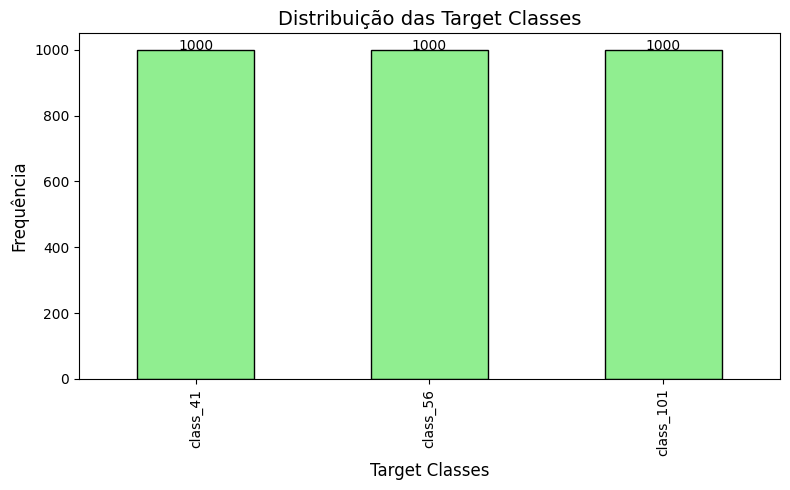

In [47]:
counts = df['target_class'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Distribuição das Target Classes', fontsize=14)
plt.xlabel('Target Classes', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

for i, value in enumerate(counts):
    plt.text(i, value + 0.2, str(value), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [48]:
round((df.isnull().sum() / df.shape[0]) * 100, 2).sort_values(ascending=False)


duration_1                       0.0
mood_pca                         0.0
acoustic_valence_mood_cluster    0.0
explicit                         0.0
signal_strength                  0.0
mode_indicator                   0.0
focus_factor                     0.0
ambient_level                    0.0
key_sin                          0.0
key_cos                          0.0
duration_log                     0.0
duration_log_z                   0.0
time_signature_class_boolean     0.0
loudness_yeo                     0.0
is_instrumental                  0.0
is_dance_hit                     0.0
temp_zscore                      0.0
resonance_factor                 0.0
timbre_index                     0.0
echo_constant                    0.0
distorted_movement               0.0
signal_power                     0.0
target_class                     0.0
mood_cluster                     0.0
loud_energy_ratio                0.0
duration_2                       0.0
energy_rank_pct                  0.0
d

In [52]:
X = df[['ambient_level']]
y = df['target_regression']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Coefficients: [-0.08471121]
Intercept: 0.4948166596280644
Mean Squared Error: 1.3709
R² Score: -0.0305
